11 ВАРИАНТ

In [1]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
import math

ЗАДАЧА 1

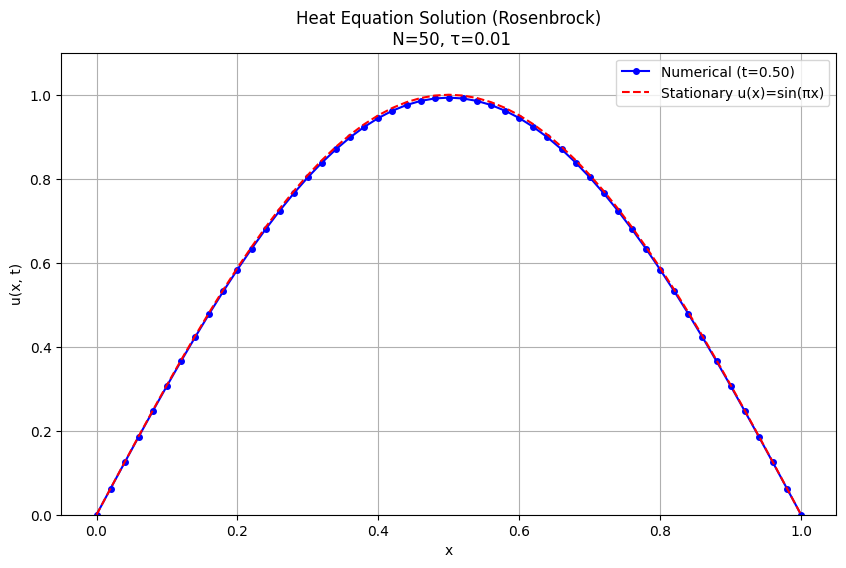

Max error vs stationary at t=0.5: 6.9307e-03


In [2]:
def solve_heat(N, Tf, dt):
    L = 1.0
    h = L / N
    x = np.linspace(0, L, N + 1)
    xi = x[1:-1]
    Ni = N - 1

    if Ni <= 0:
        return x, np.zeros_like(x)

    d0 = -2.0 / h**2 * np.ones(Ni)
    d1 = 1.0 / h**2 * np.ones(Ni - 1)
    diagonals = [d1, d0, d1]
    offsets = [-1, 0, 1]
    A = sp.diags(diagonals, offsets, shape=(Ni, Ni), format='csc')

    F = np.pi**2 * np.sin(np.pi * xi)

    gamma = (1.0 + 1.0j) / 2.0
    I = sp.identity(Ni, dtype=complex, format='csc')
    M = I - gamma * dt * A

    try:
        solver = spla.factorized(M)
    except RuntimeError:
        solver = lambda b: spla.spsolve(M, b)

    y = np.zeros(Ni, dtype=float)
    t = 0.0
    n_steps = int(np.ceil(Tf / dt))

    for n in range(n_steps):
        if t + dt > Tf:
             cdt = Tf - t
             if cdt < 1e-9: break
             M_last = I - gamma * cdt * A
             try:
                 solve_last = spla.factorized(M_last)
             except RuntimeError:
                 solve_last = lambda b: spla.spsolve(M_last, b)
             rhs = cdt * (A @ y + F)
             k = solve_last(rhs.astype(complex))
             y = y + np.real(k)
             t = Tf
             break
        else:
             cdt = dt
             rhs = cdt * (A @ y + F)
             k = solver(rhs.astype(complex))
             y = y + np.real(k)
             t += cdt

    u_final = np.zeros(N + 1)
    u_final[1:-1] = y
    return x, u_final

N_param = 50
Tf_param = 0.5
dt_param = 0.01

x_pts, u_sol = solve_heat(N_param, Tf_param, dt_param)
u_stat = np.sin(np.pi * x_pts)

plt.figure(figsize=(10, 6))
plt.plot(x_pts, u_sol, 'bo-', label=f'Numerical (t={Tf_param:.2f})', markersize=4)
plt.plot(x_pts, u_stat, 'r--', label='Stationary u(x)=sin(πx)')
plt.title(f'Heat Equation Solution (Rosenbrock)\n N={N_param}, τ={dt_param}')
plt.xlabel('x')
plt.ylabel('u(x, t)')
plt.grid(True)
plt.legend()
plt.ylim(bottom=min(0, np.min(u_sol)*1.1), top=max(1.1, np.max(u_sol)*1.1))
plt.show()

error = np.linalg.norm(u_sol - u_stat, np.inf)
print(f"Max error vs stationary at t={Tf_param}: {error:.4e}")

ЗАДАЧА 2

E(h)  : 2.8234e-01
E(h/2): 1.3633e-01
E(h/4): 6.5750e-02
Rate (p1): 1.050
Rate (p2): 1.052


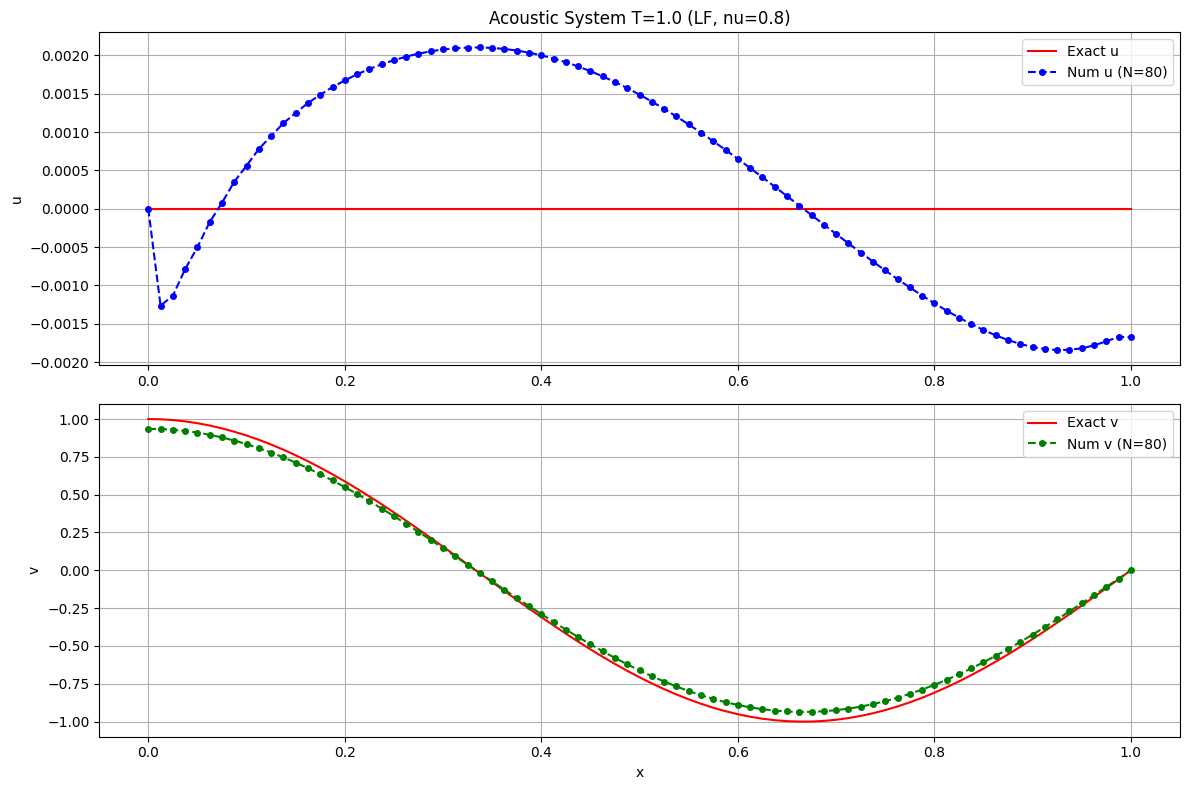

In [3]:
def exact_sol(x, t):
    omega = 1.5 * np.pi
    uex = np.cos(omega * t) * np.sin(omega * x)
    vex = -np.sin(omega * t) * np.cos(omega * x)
    return uex, vex

def solve_ac(N, T, nu):
    h = 1.0 / N
    dt = nu * h
    x = np.linspace(0, 1, N + 1)

    u_n = np.sin(1.5 * np.pi * x)
    v_n = np.zeros_like(x)

    u_np1 = np.zeros_like(u_n)
    v_np1 = np.zeros_like(v_n)

    t = 0.0
    while t < T:
        if t + dt > T:
            dt = T - t
            nu = dt / h 
            
        for j in range(1, N):
            u_np1[j] = 0.5 * (u_n[j+1] + u_n[j-1]) - 0.5 * (dt/h) * (v_n[j+1] - v_n[j-1])
            v_np1[j] = 0.5 * (v_n[j+1] + v_n[j-1]) - 0.5 * (dt/h) * (u_n[j+1] - u_n[j-1])

        u_np1[0] = 0.0
        v_np1[N] = 0.0
        v_np1[0] = v_np1[1]
        u_np1[N] = u_np1[N-1]

        u_n = u_np1.copy()
        v_n = v_np1.copy()
        t += dt
        if t >= T:
            break

    return x, u_n, v_n, h, dt

def calc_err(u_num, v_num, u_exact, v_exact):
    err_u = np.linalg.norm(u_num - u_exact, np.inf)
    err_v = np.linalg.norm(v_num - v_exact, np.inf)
    return max(err_u, err_v)

T = 1.0
nu = 0.8
N_base = 20

N1 = N_base
x1, u1, v1, h1, dt1 = solve_ac(N1, T, nu)

N2 = 2 * N_base
x2, u2, v2, h2, dt2 = solve_ac(N2, T, nu)

N3 = 4 * N_base
x3, u3, v3, h3, dt3 = solve_ac(N3, T, nu)

u_ex1, v_ex1 = exact_sol(x1, T)
u_ex2, v_ex2 = exact_sol(x2, T)
u_ex3, v_ex3 = exact_sol(x3, T)

E1 = calc_err(u1, v1, u_ex1, v_ex1)
E2 = calc_err(u2, v2, u_ex2, v_ex2)
E3 = calc_err(u3, v3, u_ex3, v_ex3)

print(f"E(h)  : {E1:.4e}")
print(f"E(h/2): {E2:.4e}")
print(f"E(h/4): {E3:.4e}")

if E1 > 0 and E2 > 0:
    p1 = math.log2(E1 / E2)
    print(f"Rate (p1): {p1:.3f}")
if E2 > 0 and E3 > 0:
    p2 = math.log2(E2 / E3)
    print(f"Rate (p2): {p2:.3f}")

plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(x3, u_ex3, 'r-', label='Exact u')
plt.plot(x3, u3, 'bo--', label=f'Num u (N={N3})', markersize=4)
plt.title(f'Acoustic System T={T} (LF, nu={nu})')
plt.ylabel('u')
plt.grid(True)
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(x3, v_ex3, 'r-', label='Exact v')
plt.plot(x3, v3, 'go--', label=f'Num v (N={N3})', markersize=4)
plt.xlabel('x')
plt.ylabel('v')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()